原始数据形状: (62988, 44)
数据所有字段: ['MEMBER_NO', 'FFP_DATE', 'FIRST_FLIGHT_DATE', 'GENDER', 'FFP_TIER', 'WORK_CITY', 'WORK_PROVINCE', 'WORK_COUNTRY', 'AGE', 'LOAD_TIME', 'FLIGHT_COUNT', 'BP_SUM', 'EP_SUM_YR_1', 'EP_SUM_YR_2', 'SUM_YR_1', 'SUM_YR_2', 'SEG_KM_SUM', 'WEIGHTED_SEG_KM', 'LAST_FLIGHT_DATE', 'AVG_FLIGHT_COUNT', 'AVG_BP_SUM', 'BEGIN_TO_FIRST', 'LAST_TO_END', 'AVG_INTERVAL', 'MAX_INTERVAL', 'ADD_POINTS_SUM_YR_1', 'ADD_POINTS_SUM_YR_2', 'EXCHANGE_COUNT', 'avg_discount', 'P1Y_Flight_Count', 'L1Y_Flight_Count', 'P1Y_BP_SUM', 'L1Y_BP_SUM', 'EP_SUM', 'ADD_Point_SUM', 'Eli_Add_Point_Sum', 'L1Y_ELi_Add_Points', 'Points_Sum', 'L1Y_Points_Sum', 'Ration_L1Y_Flight_Count', 'Ration_P1Y_Flight_Count', 'Ration_P1Y_BPS', 'Ration_L1Y_BPS', 'Point_NotFlight']
去重后数据形状: (62988, 44)

预处理后关键字段缺失值统计:
avg_discount          0
Points_Sum            0
FLIGHT_COUNT          0
AGE                   0
ADD_Point_SUM         0
L1Y_Points_Sum        0
FFP_TIER              0
Eli_Add_Point_Sum     0
EXCHANGE_COUNT   

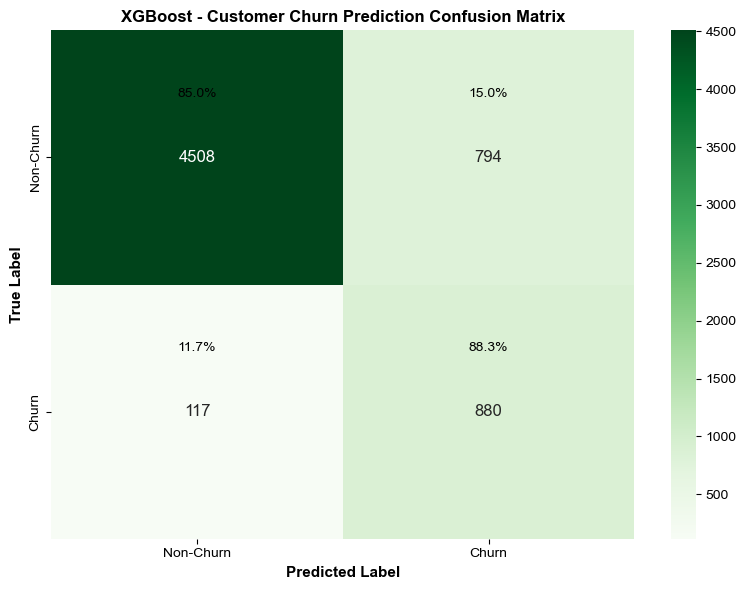

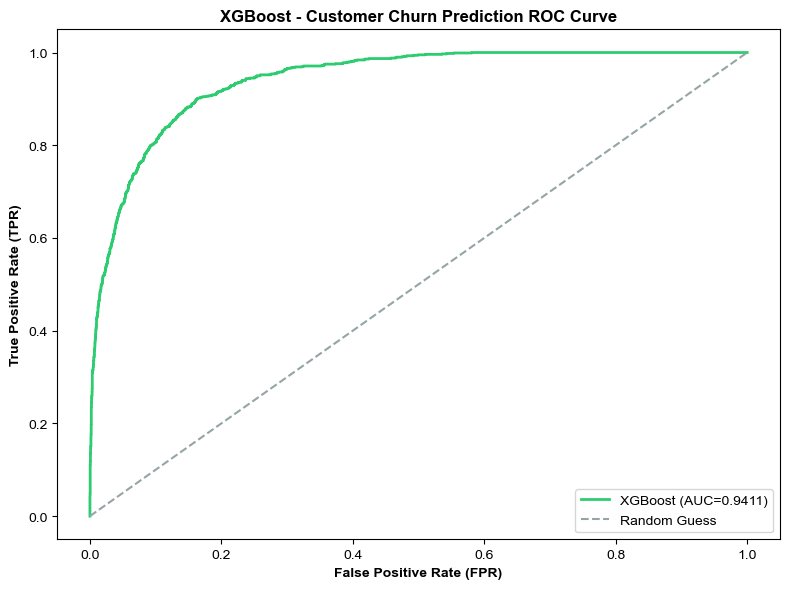

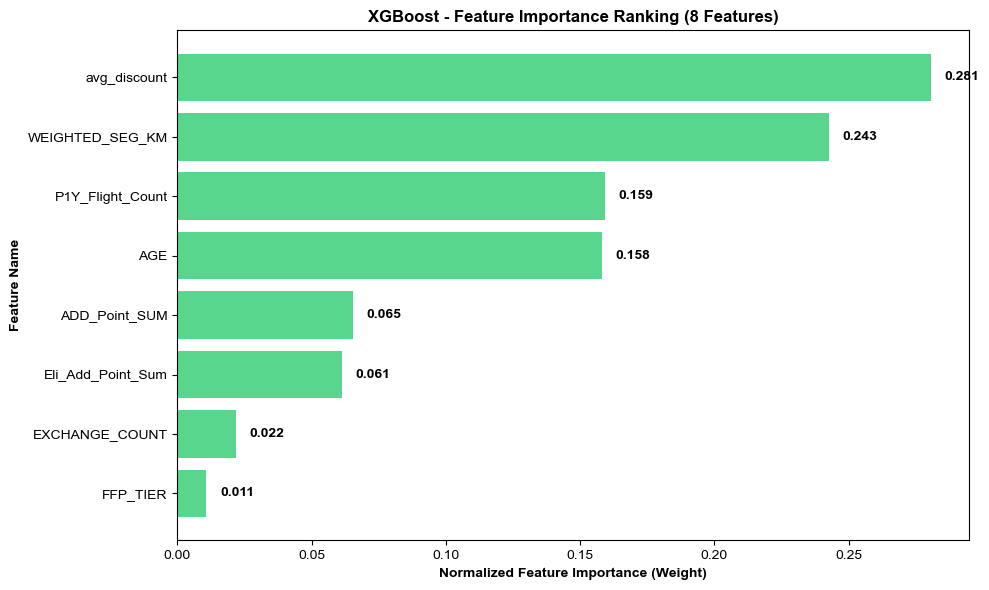

In [4]:
# ===================== 第一步：环境配置与库导入 =====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, roc_curve, confusion_matrix
)

# 全局配置
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 10
warnings.filterwarnings("ignore")  # 抑制非关键警告

# ===================== 第二步：数据读取与预处理 =====================
def load_and_preprocess_data(file_path):
    df = pd.read_csv(file_path)
    print(f"原始数据形状: {df.shape}")
    print(f"数据所有字段: {df.columns.tolist()}")
    df = df.drop_duplicates()
    print(f"去重后数据形状: {df.shape}")

    # 特征和标签字段
    feature_cols = [
        'FFP_TIER', 'AGE', 'WEIGHTED_SEG_KM', 'EXCHANGE_COUNT',
        'avg_discount', 'P1Y_Flight_Count', 'ADD_Point_SUM', 'Eli_Add_Point_Sum'
    ]
    label_cols = [
        "L1Y_Flight_Count", "L1Y_Points_Sum", "L1Y_ELi_Add_Points",
        "P1Y_Flight_Count", "FLIGHT_COUNT", "Points_Sum"
    ]
    numeric_cols = list(set(feature_cols + label_cols))
    numeric_cols = [col for col in numeric_cols if col in df.columns]

    # 数值转换+缺失值填充
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

    print("\n预处理后关键字段缺失值统计:")
    print(df[numeric_cols].isnull().sum())
    return df

# ===================== 第三步：流失标签定义 =====================
def calculate_churn_label(df):
    core_label_cols = ["L1Y_Flight_Count", "L1Y_Points_Sum", "L1Y_ELi_Add_Points"]
    missing_core_cols = [col for col in core_label_cols if col not in df.columns]
    if missing_core_cols:
        raise ValueError(f"缺失流失标签核心计算字段: {missing_core_cols}")

    inactive_now = (
        (df["L1Y_Flight_Count"] == 0) &
        (df["L1Y_Points_Sum"] == 0) &
        (df["L1Y_ELi_Add_Points"] == 0)
    )
    active_conditions = []
    if "P1Y_Flight_Count" in df.columns:
        active_conditions.append(df["P1Y_Flight_Count"] > 0)
    if "FLIGHT_COUNT" in df.columns:
        active_conditions.append(df["FLIGHT_COUNT"] > 0)
    if "Points_Sum" in df.columns:
        active_conditions.append(df["Points_Sum"] > 0)
    if not active_conditions:
        raise ValueError("无可用的历史活跃状态判断字段")
    historical_active = np.logical_or.reduce(active_conditions)

    df["is_churn"] = (inactive_now & historical_active).astype(int)
    print(f"\n流失标签分布:")
    print(df["is_churn"].value_counts())
    print(f"流失率: {df['is_churn'].mean() * 100:.2f}%")
    return df

# ===================== 第四步：数据划分 =====================
def split_data_stratified(df, feature_list, target_col="is_churn", random_state=42):
    X = df[feature_list].dropna()
    y = df.loc[X.index, target_col]
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.2, random_state=random_state, stratify=y
    )
    X_test, X_val, y_test, y_val = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=random_state, stratify=y_temp
    )
    print(f"\n数据划分结果:")
    print(f"训练集: {len(X_train)} 样本 (流失率: {y_train.mean()*100:.2f}%)")
    print(f"测试集: {len(X_test)} 样本 (流失率: {y_test.mean()*100:.2f}%)")
    print(f"验证集: {len(X_val)} 样本 (流失率: {y_val.mean()*100:.2f}%)")
    return X_train, X_test, X_val, y_train, y_test, y_val

# ===================== 第五步：XGBoost建模（修复参数+确保输出） =====================
def train_xgboost(X_train, X_val, y_train, y_val):
    # 初始化XGBoost（移除use_label_encoder，解决警告）
    xgb_model = xgb.XGBClassifier(
        objective='binary:logistic',  # 二分类任务
        eval_metric='auc',            # 评估指标为AUC
        random_state=42,
        n_jobs=-1
    )

    # 简化参数网格（避免调优时间过长）
    param_grid = {
        'n_estimators': [50, 100],    # 减少候选值，加快训练
        'max_depth': [3, 5],
        'learning_rate': [0.1, 0.2],
        'subsample': [0.8, 1.0],
        'scale_pos_weight': [len(y_train[y_train==0])/len(y_train[y_train==1])]  # 类别平衡
    }

    # 网格搜索（增加verbose=2，查看调优进度）
    grid_search = GridSearchCV(
        estimator=xgb_model,
        param_grid=param_grid,
        cv=3,  # 减少折数，加快训练
        scoring='roc_auc',
        n_jobs=-1,
        verbose=2  # 输出详细调优过程
    )

    print("\n开始XGBoost网格搜索调优...")
    grid_search.fit(X_train, y_train)

    # 强制输出最佳参数（确保不被警告干扰）
    best_xgb = grid_search.best_estimator_
    best_params = grid_search.best_params_
    cv_auc = grid_search.best_score_

    val_proba = best_xgb.predict_proba(X_val)[:, 1]
    val_auc = roc_auc_score(y_val, val_proba)

    print(f"\n===== 调优结果 =====")
    print(f"最优参数: {best_params}")
    print(f"训练集交叉验证AUC: {cv_auc:.4f}")
    print(f"验证集AUC: {val_auc:.4f}")
    return best_xgb, best_params

# ===================== 第六步：模型评估（全英文可视化） =====================
def evaluate_model(model, X_test, y_test, feature_list):
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)

    metrics = {
        "AUC": round(roc_auc_score(y_test, y_proba), 4),
        "Recall": round(recall_score(y_test, y_pred, zero_division=0), 4),
        "Precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "F1": round(f1_score(y_test, y_pred, zero_division=0), 4),
        "Accuracy": round(accuracy_score(y_test, y_pred), 4)
    }

    print("\n===================== 模型评估结果 =====================")
    print(f"AUC: {metrics['AUC']}")
    print(f"流失召回率: {metrics['Recall']} (覆盖{metrics['Recall']*100:.1f}%真实流失客户)")
    print(f"流失精确率: {metrics['Precision']}")
    print(f"F1分数: {metrics['F1']}")
    print(f"准确率: {metrics['Accuracy']}")
    print("\n详细分类报告:")
    print(classification_report(y_test, y_pred, target_names=["Non-Churn", "Churn"], digits=4))

    # 混淆矩阵可视化（全英文）
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred)
    # 计算百分比
    cm_percent = cm / cm.sum(axis=1)[:, np.newaxis] * 100

    # 使用seaborn绘制混淆矩阵
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=["Non-Churn", "Churn"],
                yticklabels=["Non-Churn", "Churn"],
                cbar=True,
                annot_kws={"size": 12})

    # 在每个格子添加百分比
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j+0.5, i+0.25, f"{cm_percent[i, j]:.1f}%",
                     ha="center", va="center", color="black", fontsize=10)

    plt.xlabel('Predicted Label', fontweight="bold", fontsize=11)
    plt.ylabel('True Label', fontweight="bold", fontsize=11)
    plt.title('XGBoost - Customer Churn Prediction Confusion Matrix', fontweight="bold", fontsize=12)
    plt.tight_layout()
    plt.show()

    # ROC曲线（保持英文标题）
    plt.figure()
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, color="#2ecc71", linewidth=2, label=f"XGBoost (AUC={metrics['AUC']})")
    plt.plot([0, 1], [0, 1], color="#95a5a6", linestyle="--", label="Random Guess")
    plt.xlabel("False Positive Rate (FPR)", fontweight="bold")
    plt.ylabel("True Positive Rate (TPR)", fontweight="bold")
    plt.title("XGBoost - Customer Churn Prediction ROC Curve", fontweight="bold")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

    # 特征重要性（全英文标题）
    plt.figure(figsize=(10, 6))
    importance = model.get_booster().get_score(importance_type='weight')
    imp_dict = {f: importance.get(f, 0) for f in feature_list}
    imp_df = pd.DataFrame({
        "Feature": imp_dict.keys(),
        "Importance": imp_dict.values()
    }).sort_values("Importance", ascending=True)
    imp_df["Importance"] = imp_df["Importance"] / imp_df["Importance"].sum()

    plt.barh(imp_df["Feature"], imp_df["Importance"], color="#2ecc71", alpha=0.8)
    for i, val in enumerate(imp_df["Importance"]):
        plt.text(val + 0.005, i, f"{val:.3f}", ha="left", va="center", fontweight="bold")
    plt.xlabel("Normalized Feature Importance (Weight)", fontweight="bold")
    plt.ylabel("Feature Name", fontweight="bold")
    plt.title("XGBoost - Feature Importance Ranking (8 Features)", fontweight="bold")
    plt.tight_layout()
    plt.show()
    return metrics

# ===================== 主流程执行 =====================
if __name__ == "__main__":
    FILE_PATH = "/Users/mac123/Downloads/air_data.csv"
    df = load_and_preprocess_data(FILE_PATH)
    df = calculate_churn_label(df)

    FEATURE_LIST = [
        'FFP_TIER', 'AGE', 'WEIGHTED_SEG_KM', 'EXCHANGE_COUNT',
        'avg_discount', 'P1Y_Flight_Count', 'ADD_Point_SUM', 'Eli_Add_Point_Sum'
    ]
    FEATURE_LIST = [col for col in FEATURE_LIST if col in df.columns]
    print(f"\n最终使用的特征列表: {FEATURE_LIST}")
    if len(FEATURE_LIST) != 8:
        missing_feat = [f for f in FEATURE_LIST if f not in df.columns]
        print(f"警告：缺失指定特征 {missing_feat}，当前仅使用 {len(FEATURE_LIST)} 个特征")

    X_train, X_test, X_val, y_train, y_test, y_val = split_data_stratified(df, FEATURE_LIST)
    best_xgb_model, best_params = train_xgboost(X_train, X_val, y_train, y_val)
    metrics = evaluate_model(best_xgb_model, X_test, y_test, FEATURE_LIST)